### News Analysis Data Extraction
Extracts article data from csv file
This will probably turn into a .py file to extract data later but just playing around right now

In [171]:
import pandas as pd

nyt_filepath = "../../project/data/raw/US-Media_NYTimesIndex_16.1.csv"
nyt_pd = pd.read_csv(nyt_filepath) # set delimiter to tab
nyt_pd.head(10)

C:\Users\marti\AppData\Local\Temp\ipykernel_41976\1215163717.py:4: DtypeWarning: Columns (3,6,17,24,25) have mixed types. Specify dtype option on import or set low_memory=False.
  nyt_pd = pd.read_csv(nyt_filepath) # set delimiter to tab


,id,year,Source,PageNumber,BeginningWords,Date,Length,FrontPage,Description,majortopic,...,FederalAgency,President,CongressDum,Courts,StateLocalActors,CandidatesCampaigns,InterestGroups,Congress,Unnamed: 25,Unnamed: 26
0,1,1946,NYT Index 1946,1,Amalganated Bank of NY,12/10/46,9,0.0,Amalganated Bank of NY to finance art purchase,15.0,...,0,0.0,0.0,0.0,0.0,0.0,0.0,79,NaN,NaN
1,2,1946,NYT Index 1946,3,Bail for Dr,11/24/46,9,0.0,Bail for Dr A. Flandina and V. Ryder halved ...,2.0,...,0,0.0,0.0,1.0,0.0,0.0,0.0,79,NaN,NaN
2,3,1946,NYT Index 1946,5,42 escape injury,10/19/46,9,0.0,42 escape injury when Pan amer Airway clipper ...,10.0,...,0,0.0,0.0,0.0,0.0,0.0,0.0,79,NaN,NaN
3,4,1946,NYT Index 1946,7,"huffman, (Col)",4/23/46,9,0.0,"Huffman, HN and 19 others killed in crash(subj...",10.0,...,0,0.0,0.0,0.0,0.0,0.0,0.0,79,NaN,NaN
4,5,1946,NYT Index 1946,9,Lifeguards J Grimmer,8/14/46,9,0.0,"Lifeguards J Grimmer, and F Garvin fined for d...",12.0,...,0,0.0,0.0,0.0,0.0,0.0,0.0,79,NaN,NaN
5,6,1946,NYT Index 1946,11,3 escape injury,3/30/46,9,0.0,3 escape injury when auto stalls on tracks,10.0,...,0,0.0,0.0,0.0,0.0,0.0,0.0,79,NaN,NaN
6,7,1946,NYT Index 1946,13,cartoon on speeding,1/20/46,9,0.0,cartoon on speeding9sujcet-accidents-motor veh...,10.0,...,0,0.0,0.0,0.0,0.0,0.0,0.0,79,NaN,NaN
7,8,1946,NYT Index 1946,15,"37 hurt,",8/6/46,9,0.0,"37 hurt, bus plungees down embankment, chicago",10.0,...,0,0.0,0.0,0.0,0.0,0.0,0.0,79,NaN,NaN
8,9,1946,NYT Index 1946,17,"Burns, (Justice)",11/16/46,9,0.0,"Burns, (Justice) F J, auto-collision, near Kin...",10.0,...,0,0.0,0.0,1.0,0.0,0.0,0.0,79,NaN,NaN
9,10,1946,NYT Index 1946,19,"Marcus, (miss)",4/30/46,9,0.0,"Marcus, (miss) J, LI RR train(subject: accidnt...",10.0,...,0,0.0,0.0,0.0,0.0,0.0,0.0,79,NaN,NaN


In [172]:
nyt_pd.columns

Index(['id', 'year', 'Source', 'PageNumber', 'BeginningWords', 'Date',
       'Length', 'FrontPage', 'Description', 'majortopic', 'NYMetro',
       'Domestic', 'myNYC', 'myNYRegion', 'myDomestic', 'myUSinvolvement',
       'PublicPolicy', 'FederalAgency', 'President', 'CongressDum', 'Courts',
       'StateLocalActors', 'CandidatesCampaigns', 'InterestGroups', 'Congress',
       'Unnamed: 25', 'Unnamed: 26'],
      dtype='object')

In [173]:
# We correct a mistake in the dataset
nyt_pd.loc[nyt_pd["Date"] == "12/24/1015", "Date"] = "12/24/15"


In [174]:
# We correct data format
month_day = nyt_pd["Date"].str.split("/", expand=True)

month = month_day[0]
day = month_day[1]

nyt_pd["full_date"] = (
    nyt_pd["year"].astype(str)
    + "-"
    + month.str.zfill(2)
    + "-"
    + day.str.zfill(2)
)
nyt_pd[["Date","year","full_date"]].head(10)

,Date,year,full_date
0,12/10/46,1946,1946-12-10
1,11/24/46,1946,1946-11-24
2,10/19/46,1946,1946-10-19
3,4/23/46,1946,1946-04-23
4,8/14/46,1946,1946-08-14
5,3/30/46,1946,1946-03-30
6,1/20/46,1946,1946-01-20
7,8/6/46,1946,1946-08-06
8,11/16/46,1946,1946-11-16
9,4/30/46,1946,1946-04-30


In [175]:
# Convert to datatime
nyt_pd["full_date"] = pd.to_datetime(nyt_pd["full_date"])

#  Index by date
nyt_pd_indexed = nyt_pd.set_index("full_date")

In [ ]:
nyt_pd_indexed = nyt_pd_indexed.rename(columns={
    "Description": "text",
    "Source": "source"
})
nyt_pd_indexed.index.name = "date"
nyt_pd_indexed.head(10)


,id,year,source,PageNumber,BeginningWords,Date,Length,FrontPage,text,majortopic,...,FederalAgency,President,CongressDum,Courts,StateLocalActors,CandidatesCampaigns,InterestGroups,Congress,Unnamed: 25,Unnamed: 26
full_date,,,,,,,,,,,,,,,,,,,,,
1946-01-01,306,1946,NYT Index 1946,611,J F Pietrafesa,1/1/46,9,0.0,NYC-Marshals: J F Pietrafesa apptd City Marshal.,24.0,...,0,0.0,0.0,0.0,1.0,0.0,0.0,79,NaN,NaN
1946-01-02,229,1946,NYT Index 1946,457,Shot to death in,1/2/46,9,0.0,Pasquale Cicarelli: shot to death in Berlin; 2...,16.0,...,0,0.0,0.0,0.0,0.0,0.0,0.0,79,NaN,NaN
1946-01-02,118,1946,NYT Index 1946,235,death-sentence appeal,1/2/46,9,0.0,"Laszlo de Bardossy, death-sentence appeal denied;",12.0,...,0,0.0,0.0,1.0,0.0,0.0,0.0,79,NaN,NaN
1946-01-02,807,1946,NYT Index 1946,1613,takes oath as,1/2/46,9,0.0,"Noses, (Como) Robert takes oath as Park Comr a...",24.0,...,0,0.0,0.0,0.0,1.0,0.0,0.0,79,NaN,NaN
1946-01-02,180,1946,NYT Index 1946,359,returns to Iran,1/2/46,9,0.0,Smb sir Raeder W Bullard returns to Iran; conf...,19.0,...,0,0.0,0.0,0.0,0.0,0.0,0.0,79,NaN,NaN
1946-01-03,113,1946,NYT Index 1946,225,USSR desires for,1/3/46,9,0.0,US Govt foreign loans policy: USSR desire for ...,18.0,...,1,0.0,0.0,0.0,0.0,0.0,0.0,79,NaN,NaN
1946-01-03,559,1946,NYT Index 1946,1117,US MIL Comm,1/3/46,9,0.0,War Crime Trial: US Mil Comm denies dismissal ...,16.0,...,1,0.0,0.0,0.0,0.0,0.0,0.0,79,NaN,NaN
1946-01-03,843,1946,NYT Index 1946,1685,F C Bals sworn,1/3/46,9,0.0,NYC Police Department: F C Bals sworn in as de...,24.0,...,0,0.0,0.0,0.0,1.0,0.0,0.0,79,NaN,NaN
1946-01-03,816,1946,NYT Index 1946,1631,S Gunn charged with,1/3/46,9,0.0,NYC: S Gunn charged with pushing man in front ...,12.0,...,0,0.0,0.0,0.0,1.0,0.0,0.0,79,NaN,NaN


In [177]:
# Sort by date
nyt_pd_indexed = nyt_pd_indexed.sort_index()
nyt_pd_indexed.head(10)


,id,year,source,PageNumber,BeginningWords,Date,Length,FrontPage,text,majortopic,...,FederalAgency,President,CongressDum,Courts,StateLocalActors,CandidatesCampaigns,InterestGroups,Congress,Unnamed: 25,Unnamed: 26
full_date,,,,,,,,,,,,,,,,,,,,,
1946-01-01,306,1946,NYT Index 1946,611,J F Pietrafesa,1/1/46,9,0.0,NYC-Marshals: J F Pietrafesa apptd City Marshal.,24.0,...,0,0.0,0.0,0.0,1.0,0.0,0.0,79,NaN,NaN
1946-01-02,229,1946,NYT Index 1946,457,Shot to death in,1/2/46,9,0.0,Pasquale Cicarelli: shot to death in Berlin; 2...,16.0,...,0,0.0,0.0,0.0,0.0,0.0,0.0,79,NaN,NaN
1946-01-02,118,1946,NYT Index 1946,235,death-sentence appeal,1/2/46,9,0.0,"Laszlo de Bardossy, death-sentence appeal denied;",12.0,...,0,0.0,0.0,1.0,0.0,0.0,0.0,79,NaN,NaN
1946-01-02,807,1946,NYT Index 1946,1613,takes oath as,1/2/46,9,0.0,"Noses, (Como) Robert takes oath as Park Comr a...",24.0,...,0,0.0,0.0,0.0,1.0,0.0,0.0,79,NaN,NaN
1946-01-02,180,1946,NYT Index 1946,359,returns to Iran,1/2/46,9,0.0,Smb sir Raeder W Bullard returns to Iran; conf...,19.0,...,0,0.0,0.0,0.0,0.0,0.0,0.0,79,NaN,NaN
1946-01-03,113,1946,NYT Index 1946,225,USSR desires for,1/3/46,9,0.0,US Govt foreign loans policy: USSR desire for ...,18.0,...,1,0.0,0.0,0.0,0.0,0.0,0.0,79,NaN,NaN
1946-01-03,559,1946,NYT Index 1946,1117,US MIL Comm,1/3/46,9,0.0,War Crime Trial: US Mil Comm denies dismissal ...,16.0,...,1,0.0,0.0,0.0,0.0,0.0,0.0,79,NaN,NaN
1946-01-03,843,1946,NYT Index 1946,1685,F C Bals sworn,1/3/46,9,0.0,NYC Police Department: F C Bals sworn in as de...,24.0,...,0,0.0,0.0,0.0,1.0,0.0,0.0,79,NaN,NaN
1946-01-03,816,1946,NYT Index 1946,1631,S Gunn charged with,1/3/46,9,0.0,NYC: S Gunn charged with pushing man in front ...,12.0,...,0,0.0,0.0,0.0,1.0,0.0,0.0,79,NaN,NaN


In [178]:
# We check dates are correct
print(nyt_pd_indexed.index.min())
print(nyt_pd_indexed.index.max())

1946-01-01 00:00:00
2016-12-30 00:00:00


In [179]:
# Drop na values in Description
nyt_pd_indexed.dropna(subset=['text'], inplace=True)
nyt_pd_indexed.head(10)

,id,year,source,PageNumber,BeginningWords,Date,Length,FrontPage,text,majortopic,...,FederalAgency,President,CongressDum,Courts,StateLocalActors,CandidatesCampaigns,InterestGroups,Congress,Unnamed: 25,Unnamed: 26
full_date,,,,,,,,,,,,,,,,,,,,,
1946-01-01,306,1946,NYT Index 1946,611,J F Pietrafesa,1/1/46,9,0.0,NYC-Marshals: J F Pietrafesa apptd City Marshal.,24.0,...,0,0.0,0.0,0.0,1.0,0.0,0.0,79,NaN,NaN
1946-01-02,229,1946,NYT Index 1946,457,Shot to death in,1/2/46,9,0.0,Pasquale Cicarelli: shot to death in Berlin; 2...,16.0,...,0,0.0,0.0,0.0,0.0,0.0,0.0,79,NaN,NaN
1946-01-02,118,1946,NYT Index 1946,235,death-sentence appeal,1/2/46,9,0.0,"Laszlo de Bardossy, death-sentence appeal denied;",12.0,...,0,0.0,0.0,1.0,0.0,0.0,0.0,79,NaN,NaN
1946-01-02,807,1946,NYT Index 1946,1613,takes oath as,1/2/46,9,0.0,"Noses, (Como) Robert takes oath as Park Comr a...",24.0,...,0,0.0,0.0,0.0,1.0,0.0,0.0,79,NaN,NaN
1946-01-02,180,1946,NYT Index 1946,359,returns to Iran,1/2/46,9,0.0,Smb sir Raeder W Bullard returns to Iran; conf...,19.0,...,0,0.0,0.0,0.0,0.0,0.0,0.0,79,NaN,NaN
1946-01-03,113,1946,NYT Index 1946,225,USSR desires for,1/3/46,9,0.0,US Govt foreign loans policy: USSR desire for ...,18.0,...,1,0.0,0.0,0.0,0.0,0.0,0.0,79,NaN,NaN
1946-01-03,559,1946,NYT Index 1946,1117,US MIL Comm,1/3/46,9,0.0,War Crime Trial: US Mil Comm denies dismissal ...,16.0,...,1,0.0,0.0,0.0,0.0,0.0,0.0,79,NaN,NaN
1946-01-03,843,1946,NYT Index 1946,1685,F C Bals sworn,1/3/46,9,0.0,NYC Police Department: F C Bals sworn in as de...,24.0,...,0,0.0,0.0,0.0,1.0,0.0,0.0,79,NaN,NaN
1946-01-03,816,1946,NYT Index 1946,1631,S Gunn charged with,1/3/46,9,0.0,NYC: S Gunn charged with pushing man in front ...,12.0,...,0,0.0,0.0,0.0,1.0,0.0,0.0,79,NaN,NaN


In [180]:
# Count number of total articles
indexed_numrows = len(nyt_pd_indexed)
indexed_numrows

56909

In [181]:
# Use indexed and sorted data to search for articles that contain the keyword "deflation" in them
nyt_pd_keyword_deflation = nyt_pd_indexed[nyt_pd_indexed['Description'].str.contains('deflation', case=False)]
nyt_pd_keyword_deflation.head(10)

KeyError: 'Description'

In [ ]:
# Count number of articles that contain keyword (compared to the total 12724)
keyword_numrows = len(nyt_pd_keyword_deflation)
keyword_numrows

5

In [ ]:
# We try another keyword
nyt_pd_keyword_inflation = nyt_pd_indexed[nyt_pd_indexed['Description'].str.contains('inflation', case=False)]
nyt_pd_keyword_inflation.head(10)

,id,year,Source,PageNumber,BeginningWords,Date,Length,FrontPage,Description,majortopic,...,FederalAgency,President,CongressDum,Courts,StateLocalActors,CandidatesCampaigns,InterestGroups,Congress,Unnamed: 25,Unnamed: 26
full_date,,,,,,,,,,,,,,,,,,,,,
1946-11-03,457,1946,NYT Index 1946,913,Pres Bldault's warning,11/3/46,9,0.0,France-Economic Conditions: Pres Bladault's wa...,19.0,...,0,0.0,0.0,0.0,0.0,0.0,0.0,79,NaN,NaN
1946-11-20,242,1946,NYT Index 1946,483,"ed, ONE-MAN inflation",11/20/46,9,0.0,"Coal--US: ed, One-Man inflation",8.0,...,0,0.0,0.0,0.0,0.0,0.0,0.0,79,NaN,NaN
1947-09-28,1987,1947,NYT Index 1947,2215,Eastern subcom aims,9/28/47,9,0.0,Eastern subcom aims and data from hearings rev...,1.0,...,0,0.0,1.0,0.0,0.0,0.0,0.0,80,NaN,NaN
1947-12-21,1583,1947,NYT Index 1947,1407,Lr on inflation control,12/21/47,9,0.0,letter on inflation control,1.0,...,0,0.0,0.0,0.0,0.0,0.0,0.0,80,NaN,NaN
1952-02-10,5077,1952,NYT Index 1952,1165,Prof Slichter sees,2/10/52,9,0.0,Prof sees new wage rises bringing price rises ...,1.0,...,0,0.0,0.0,0.0,0.0,0.0,0.0,82,NaN,NaN
1953-01-22,5686,1953,NYT Index 1953,1099,A Sproul urges productivity,1/22/53,9,0.0,A Sproul urges productivity as inflation bar,1.0,...,0,0.0,0.0,0.0,0.0,0.0,0.0,83,NaN,NaN
1953-09-20,5152,1953,NYT Index 1953,25,Sen Dirksen charges Truman,9/20/53,9,0.0,Sen Dirksen charges Truman Adm kept agri. pric...,4.0,...,0,1.0,1.0,0.0,0.0,0.0,1.0,83,NaN,NaN
1956-06-10,7232,1956,NYT Index 1956,508,Bevan ascribes inflation,6/10/56,9,0.0,MP Bevan of Great Britain ascribes inflation ...,19.0,...,1,0.0,0.0,0.0,0.0,0.0,0.0,84,NaN,NaN
1956-09-12,7376,1956,NYT Index 1956,798,Assn charges Adm,9/12/56,9,0.0,Assn charges Adm 'money mgrs' restrict mortgag...,15.0,...,0,1.0,0.0,0.0,0.0,0.0,0.0,84,NaN,NaN


In [ ]:
len(nyt_pd_keyword_inflation)

153

## Count Function

Define a function to get article count containing keyword - start of migrating to .py files

Use python file keywords.py

In [ ]:
import importlib
import keywords

importlib.reload(keywords)
from keywords import CATEGORY_KEYWORDS

In [ ]:
from keywords import CATEGORY_KEYWORDS          # ← ADD: import the shared dictionary

def keyword_article_count(keyword, df):
    return df['text'].str.contains(keyword, case=False, na=False).sum()

rows = []
for category, keywords in CATEGORY_KEYWORDS.items():   # ← CHANGE: categories → CATEGORY_KEYWORDS
    for kw in keywords:
        count = keyword_article_count(kw, JPnews_pd_indexed)
        rows.append({"category": category, "keyword": kw, "article_count": count})

results_df = pd.DataFrame(rows).sort_values(["category", "article_count"], ascending=[True, False])
results_df


NameError: name 'JPnews_pd_indexed' is not defined

In [ ]:
results_df.head(10)

,category,keyword,article_count
16,defense,war,5553
6,defense,security,5519
3,defense,china,401
4,defense,military,195
14,defense,defense,195
19,defense,russia,184
2,defense,north korea,163
12,defense,threat,128
1,defense,self-defense,62
18,defense,army,52


In [ ]:
len(JPnews_pd_indexed)

5595

In [ ]:
def category_article_count(keywords, df):
    pattern = "|".join(keywords)
    return df['text'].str.contains(pattern, case=False, na=False).sum()

rows = []
for category, keywords in CATEGORY_KEYWORDS.items():   # ← CHANGE: categories → CATEGORY_KEYWORDS
    count = category_article_count(keywords, JPnews_pd_indexed)
    rows.append({"category": category, "unique_articles": count})

category_totals = pd.DataFrame(rows).sort_values("unique_articles", ascending=False)
category_totals

,category,unique_articles
1,economy,1515
0,defense,1104
2,nuclear,263
3,immigration,208


Normalisation of article count  


In [ ]:
yearly_count = JPnews_pd_indexed.groupby(JPnews_pd_indexed.index.year).size()
print(yearly_count)

date
2004    224
2005    261
2006    445
2007    790
2008     95
2009     95
2010    318
2011    169
2012    175
2013    542
2014    289
2015    430
2016    171
2017    252
2018    246
2019    569
2020    222
2021    302
dtype: int64


In [ ]:

JPnews_pd_indexed['year'] = JPnews_pd_indexed.index.year

def category_article_count_by_year(keywords, df):
    pattern = "|".join(keywords)
    mask = df['text'].str.contains(pattern, case=False, na=False)
    return df[mask].groupby('year').size()

# Total articles per year (denominator)
total_per_year = JPnews_pd_indexed.groupby('year').size()

# Count matching articles per category per year, then normalise
rows = []
for category, keywords in CATEGORY_KEYWORDS.items():
    counts_by_year = category_article_count_by_year(keywords, JPnews_pd_indexed)
    normalised = (counts_by_year / total_per_year).fillna(0)
    
    for year, norm_value in normalised.items():
        rows.append({
            "category": category,
            "year": year,
            "article_count": counts_by_year.get(year, 0),
            "total_articles": total_per_year[year],
            "normalised_share": norm_value
        })

category_normalised = pd.DataFrame(rows).sort_values(["category", "year"])
category_normalised.head(50)

,category,year,article_count,total_articles,normalised_share
0,defense,2004,44,224,0.196429
1,defense,2005,47,261,0.180077
2,defense,2006,72,445,0.161798
3,defense,2007,109,790,0.137975
4,defense,2008,11,95,0.115789
5,defense,2009,7,95,0.073684
6,defense,2010,43,318,0.135220
7,defense,2011,21,169,0.124260
8,defense,2012,27,175,0.154286
9,defense,2013,76,542,0.140221


## Graph Function

Define a function to graph article with keyword occurences over time

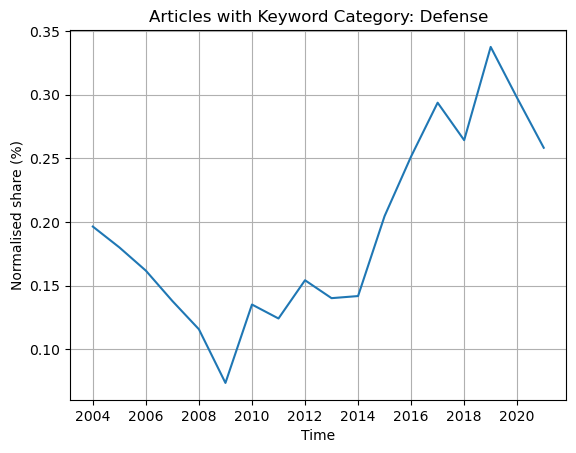

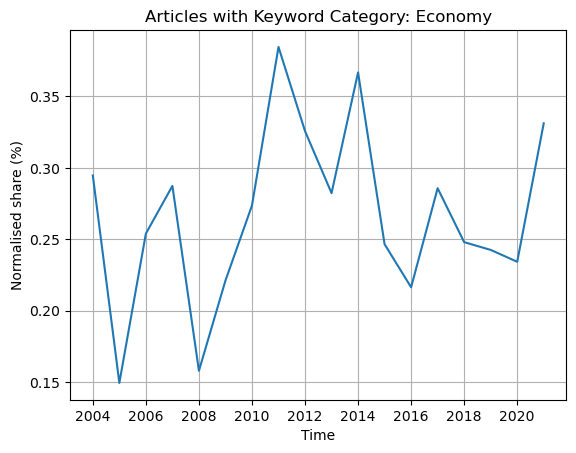

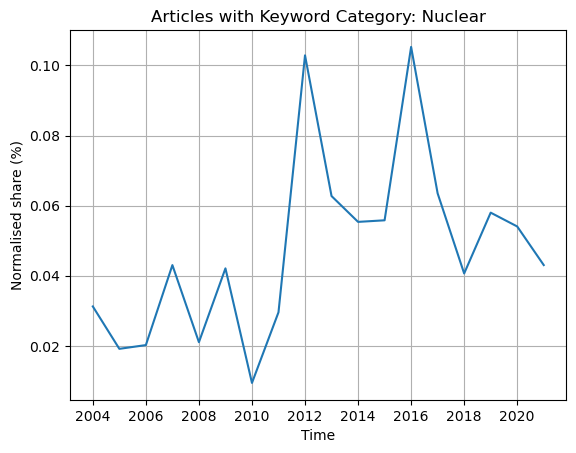

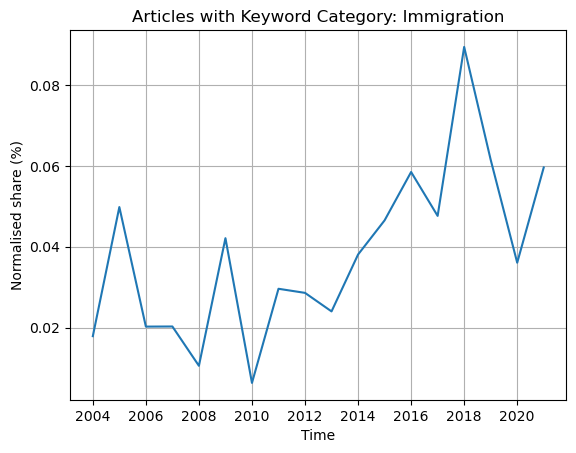

In [ ]:
import matplotlib.pyplot as plt

def category_graph(category_name, category_normalised, x_title, y_title, main_title):

    df_plot = category_normalised[category_normalised['category'] == category_name]

    fig, ax = plt.subplots()
    ax.plot(df_plot['year'].astype(int), df_plot['normalised_share'])
    ax.xaxis.set_major_locator(plt.MaxNLocator(integer=True))
    ax.set_xlabel(x_title)
    ax.set_ylabel(y_title)
    ax.set_title(main_title)
    ax.grid(True)
    
    return fig

# Save the figure
for category in CATEGORY_KEYWORDS.keys():
 fig = category_graph(
        category_name=category,
        category_normalised=category_normalised,       
        x_title="Time",
        y_title="Normalised share (%)",
        main_title=f"Articles with Keyword Category: {category.capitalize()}"
    )
 fig.savefig(f"{category}_articles_plot.png", bbox_inches='tight', dpi=300)
 plt.show()

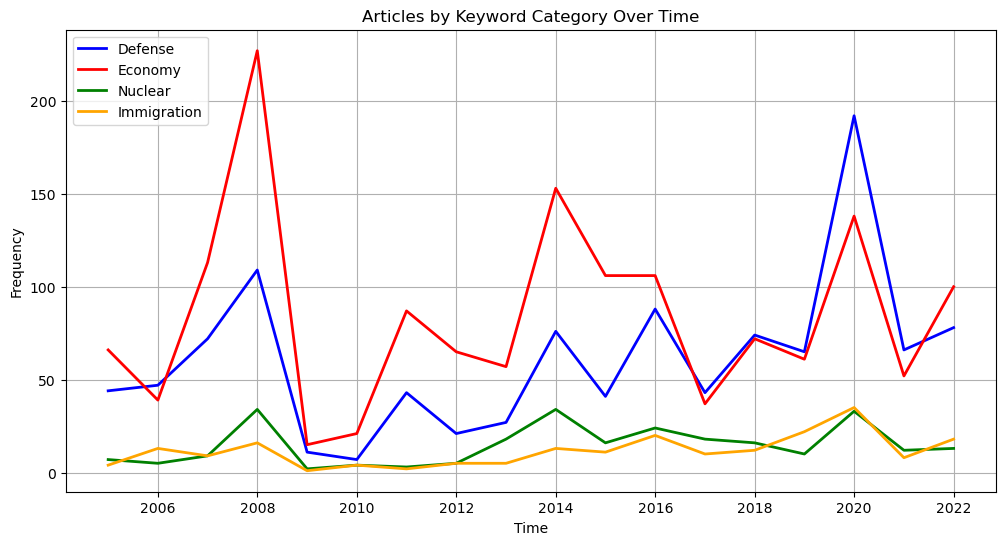

In [ ]:
import matplotlib.pyplot as plt

COLORS = ['blue', 'red', 'green', 'orange']

fig, ax = plt.subplots(figsize=(12, 6))

for (category, keywords), color in zip(CATEGORY_KEYWORDS.items(), COLORS):
    pattern = "|".join(keywords)
    JPnews_pd_keyword = JPnews_pd_indexed[JPnews_pd_indexed['text'].str.contains(pattern, case=False, na=False)]
    df_plot = JPnews_pd_keyword.resample('YE').size()
    ax.plot(df_plot.index, df_plot.values, label=category.capitalize(), color=color, linewidth=2)

ax.set_xlabel("Time")
ax.set_ylabel("Frequency")
ax.set_title("Articles by Keyword Category Over Time")
ax.legend(loc='upper left')
ax.grid(True)

fig.savefig("combined_categories_plot.png", bbox_inches='tight', dpi=300)
plt.show()

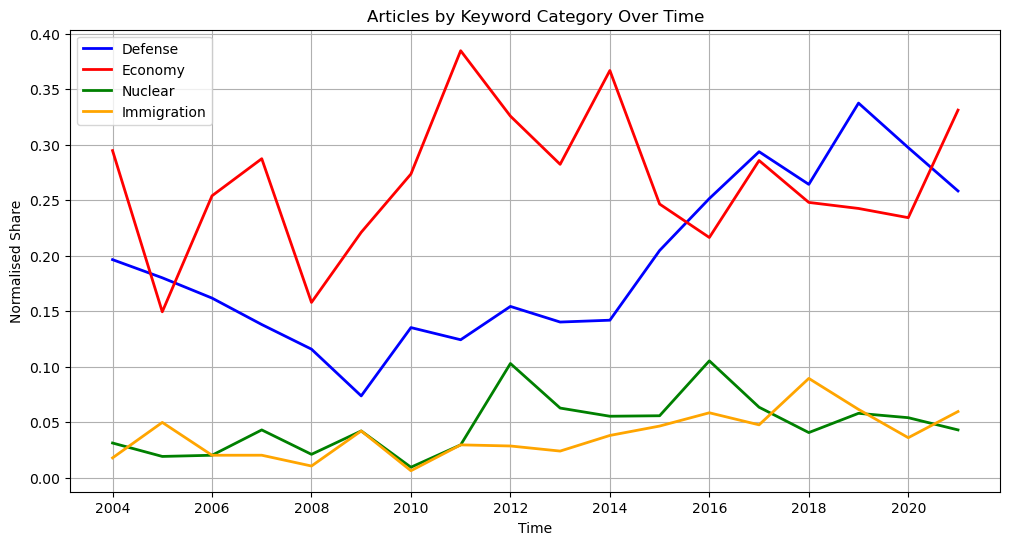

In [ ]:
import matplotlib.pyplot as plt

COLORS = ['blue', 'red', 'green', 'orange']

fig, ax = plt.subplots(figsize=(12, 6))

for category, color in zip(CATEGORY_KEYWORDS.keys(), COLORS):  # ← CHANGE: removed `keywords` from loop
    df_plot = category_normalised[category_normalised['category'] == category]  # ← CHANGE: replaced pattern matching + resample with filter
    ax.plot(df_plot['year'].astype(int), df_plot['normalised_share'], label=category.capitalize(), color=color, linewidth=2)  # ← CHANGE: replaced df_plot.index, df_plot.values with year and normalised_share; added astype(int)

ax.set_xlabel("Time")
ax.set_ylabel("Normalised Share")  # ← CHANGE: updated y-axis label
ax.set_title("Articles by Keyword Category Over Time")
ax.xaxis.set_major_locator(plt.MaxNLocator(integer=True))  # ← ADD: force integer x-axis ticks
ax.legend(loc='upper left')
ax.grid(True)

fig.savefig("combined_categories_plot.png", bbox_inches='tight', dpi=300)
plt.show()

Regression analysis 

In [ ]:
speeches_normalised = pd.read_csv('../data/clean/speeches_normalised.csv')
merged_df = pd.merge(speeches_normalised, category_normalised, on=['category', 'year'], suffixes=('_speeches', '_articles'))
merged_df

,category,year,keyword_speeches,total_speeches,normalised_share_speeches,article_count,total_articles,normalised_share_articles
0,defense,2004,0,0,NaN,44,224,0.196429
1,defense,2005,3,4,0.750000,47,261,0.180077
2,defense,2006,1,3,0.333333,72,445,0.161798
3,defense,2007,1,1,1.000000,109,790,0.137975
4,defense,2008,5,5,1.000000,11,95,0.115789
...,...,...,...,...,...,...,...,...
67,nuclear,2017,10,37,0.270270,16,252,0.063492
68,nuclear,2018,6,20,0.300000,10,246,0.040650
69,nuclear,2019,7,22,0.318182,33,569,0.057996
70,nuclear,2020,5,15,0.333333,12,222,0.054054


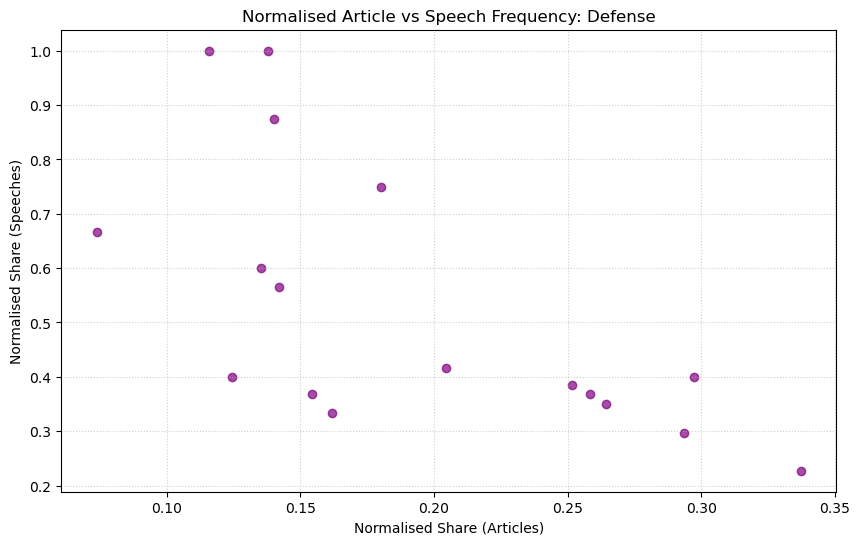

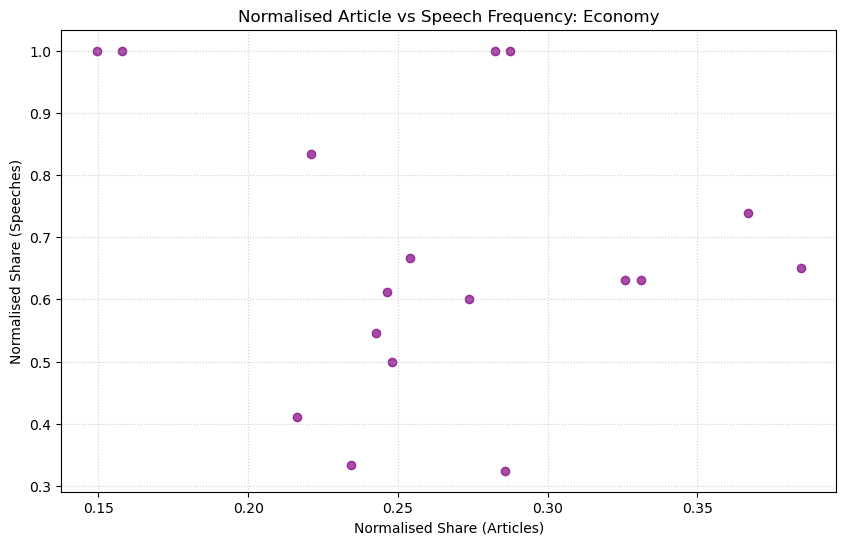

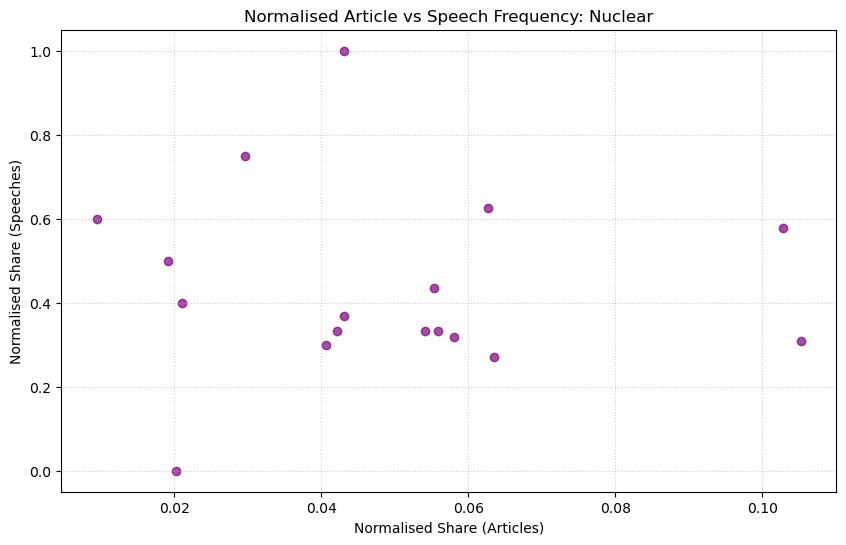

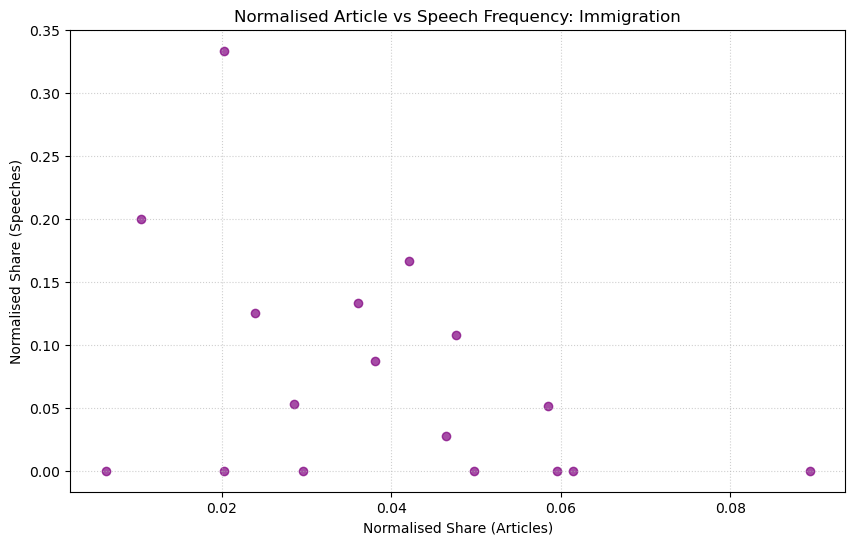

In [ ]:
for category in CATEGORY_KEYWORDS.keys():
    df_plot = merged_df[merged_df['category'] == category]

    plt.figure(figsize=(10, 6))
    plt.scatter(x=df_plot['normalised_share_articles'], y=df_plot['normalised_share_speeches'], color='purple', alpha=0.7)

    plt.title(f"Normalised Article vs Speech Frequency: {category.capitalize()}")
    plt.xlabel("Normalised Share (Articles)")
    plt.ylabel("Normalised Share (Speeches)")
    plt.grid(True, linestyle=':', alpha=0.6)
    plt.show()

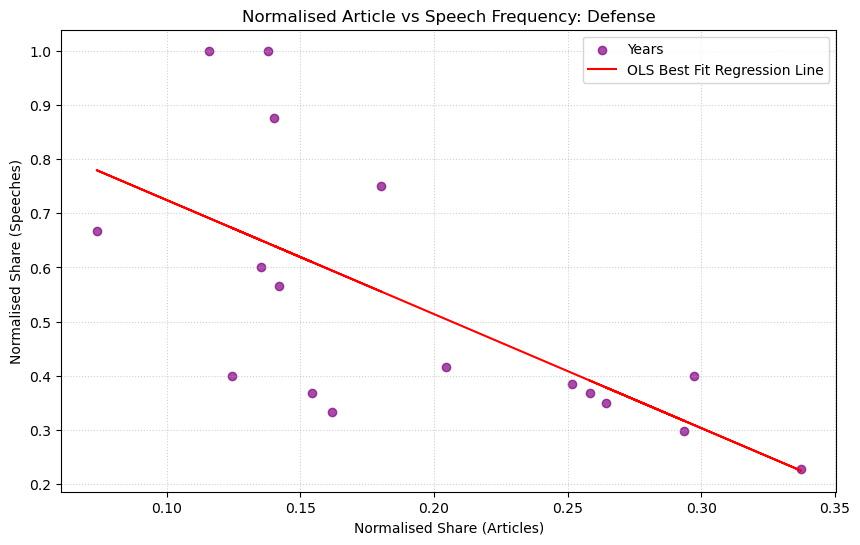

Defense: R²=0.429, p-value=0.004


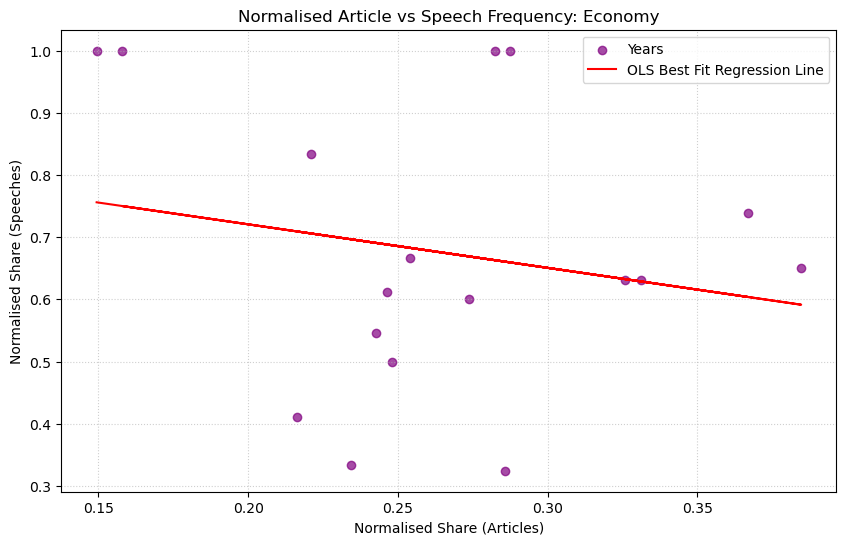

Economy: R²=0.039, p-value=0.448


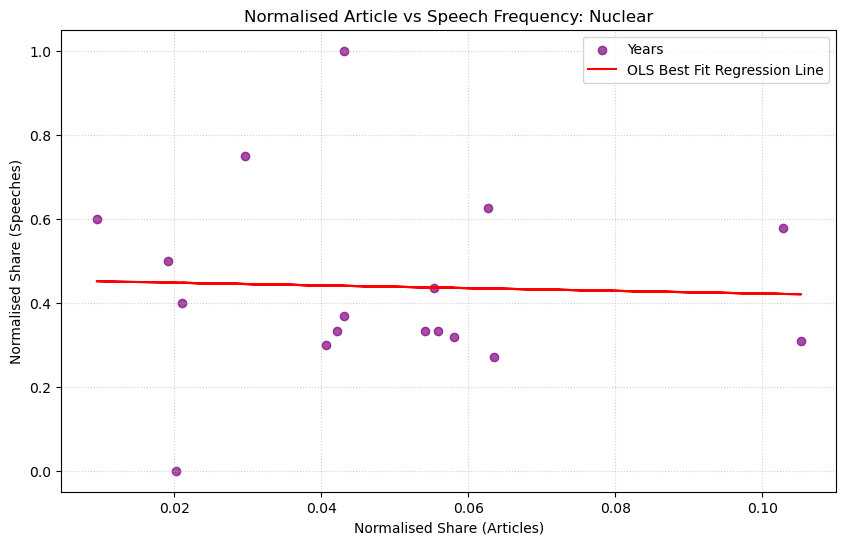

Nuclear: R²=0.001, p-value=0.884


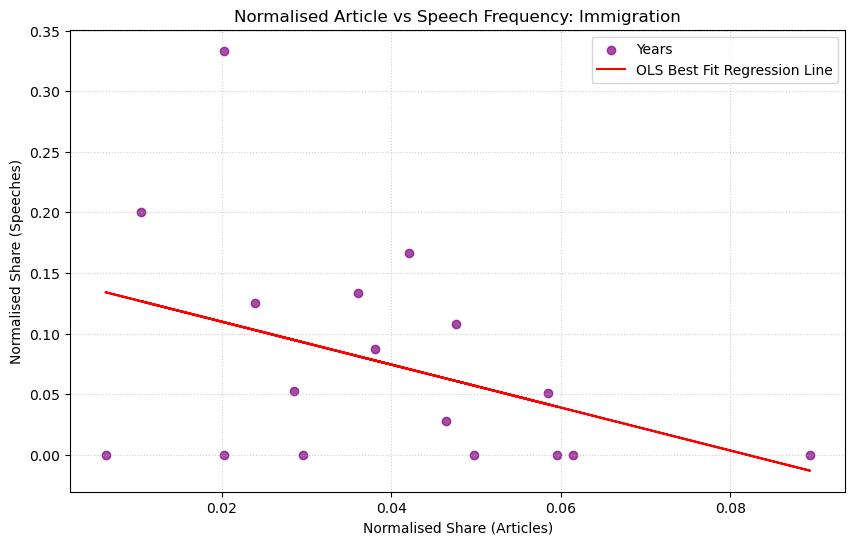

Immigration: R²=0.159, p-value=0.113


In [ ]:
import statsmodels.api as sm

for category in CATEGORY_KEYWORDS.keys():
    df_plot = merged_df[merged_df['category'] == category].dropna()

    X = sm.add_constant(df_plot['normalised_share_articles'])
    y = df_plot['normalised_share_speeches']
    model = sm.OLS(y, X).fit()

    intercept, slope = model.params.iloc[0], model.params.iloc[1]

    plt.figure(figsize=(10, 6))
    plt.scatter(df_plot['normalised_share_articles'], df_plot['normalised_share_speeches'], color='purple', alpha=0.7, label='Years')
    plt.plot(df_plot['normalised_share_articles'], intercept + slope * df_plot['normalised_share_articles'], color='red', label='OLS Best Fit Regression Line')

    plt.title(f"Normalised Article vs Speech Frequency: {category.capitalize()}")
    plt.xlabel("Normalised Share (Articles)")
    plt.ylabel("Normalised Share (Speeches)")
    plt.legend()
    plt.grid(True, linestyle=':', alpha=0.6)
    plt.show()

    print(f"{category.capitalize()}: R²={model.rsquared:.3f}, p-value={model.pvalues.iloc[1]:.3f}")

## Notes

It looks like pre-2004 has much more articles and we should consider this period an outlier that skews our results and just cut it out. Maybe begin our timeline from 2005? Or normalize - divide by total articles so measure by proportion not frequency.